# Economic Vulnerability Analysis by Age

**2024 SHED Survey - Federal Reserve**

Analysis of economic vulnerability metrics across age groups to measure whether technology's promises of abundance are translating into real economic outcomes.

**Sample:** Non-retired respondents (N=7,858)

**Age Groups:** 
- 18-29 years
- 30-44 years  
- 45+ years

In [69]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

In [70]:
# Load the dataset
df = pd.read_csv('data_optimized.csv', low_memory=False)

print(f"Dataset loaded: {len(df):,} respondents, {len(df.columns)} variables")
print(f"\nOriginal age category breakdown (ppagect4):")
print(df['ppagect4'].value_counts().sort_index())

Dataset loaded: 7,858 respondents, 385 variables

Original age category breakdown (ppagect4):
ppagect4
18–29    1752
30–44    2600
45–59    2414
60+      1092
Name: count, dtype: int64


In [71]:
# Create 3-group age categorization: 18-29, 30-44, 45+
def categorize_age_3groups(age_cat):
    if age_cat == '18–29':
        return '18-29'
    elif age_cat == '30–44':
        return '30-44'
    elif age_cat in ['45–59', '60+']:
        return '45+'
    else:
        return None

df['age_3groups'] = df['ppagect4'].apply(categorize_age_3groups)

print("\nNew 3-group age breakdown:")
print(df['age_3groups'].value_counts().sort_index())
print(f"\nTotal respondents with valid age data: {df['age_3groups'].notna().sum():,}")


New 3-group age breakdown:
age_3groups
18-29    1752
30-44    2600
45+      3506
Name: count, dtype: int64

Total respondents with valid age data: 7,858


---
## Chart 1: Overall Financial Situation by Age

**Variable:** B2 - Self-reported financial wellbeing

**Insight:** This is the ultimate outcome metric - are people actually experiencing abundance?

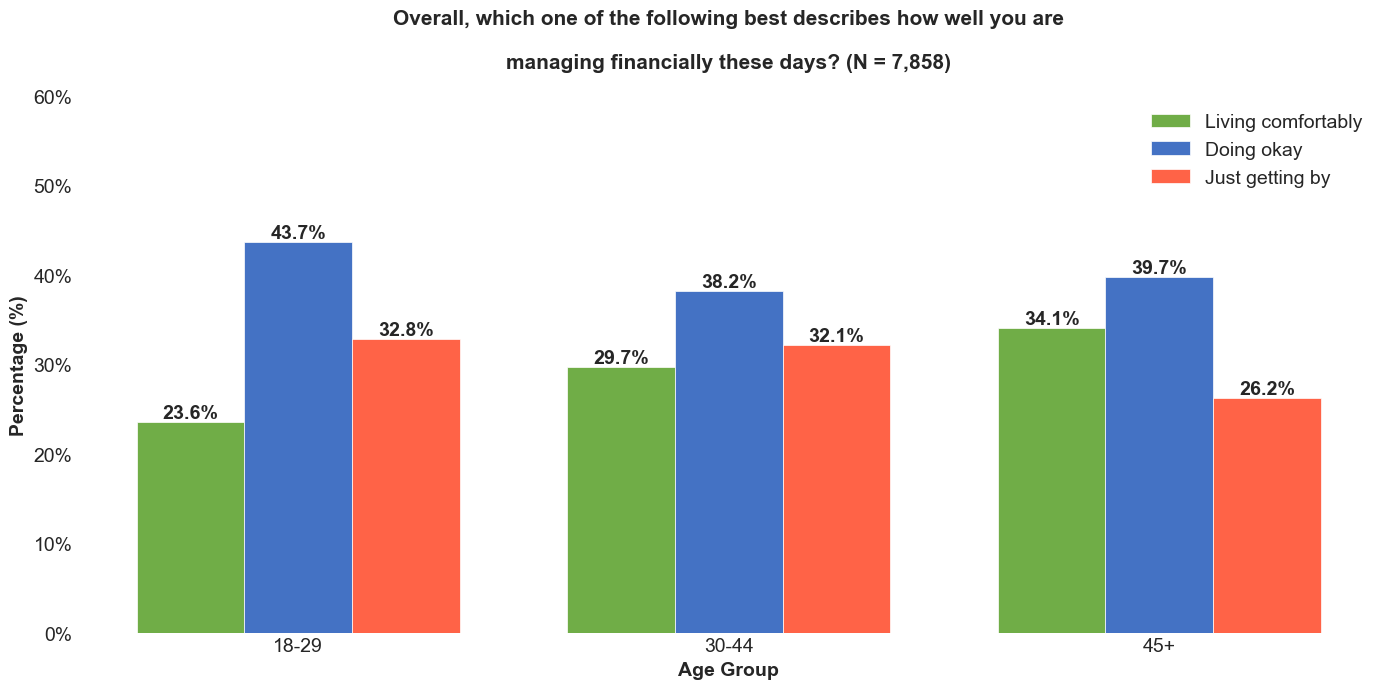


Overall Financial Situation by Age:
B2_grouped   Living comfortably  Doing okay  Just getting by
age_3groups                                                 
18-29                     23.60       43.70            32.80
30-44                     29.70       38.20            32.10
45+                       34.10       39.70            26.20

Total respondents included: 7,858


In [72]:
# Chart 1: Overall Financial Situation (B2) by Age

# Define age groups
age_groups = ['18-29', '30-44', '45+']

# Filter data
df_chart1 = df[df['age_3groups'].isin(age_groups) & df['B2'].notna()].copy()

# Create grouped B2 category combining "just getting by" and "finding it difficult"
df_chart1['B2_grouped'] = df_chart1['B2'].apply(
    lambda x: 'Just getting by' if x in ['Just getting by', 'Finding it difficult to get by'] 
    else x
)

# Create crosstab with percentages
financial_by_age = pd.crosstab(df_chart1['age_3groups'], df_chart1['B2_grouped'], normalize='index') * 100

# Define the order of financial situation categories (from best to worst)
financial_order = ['Living comfortably', 'Doing okay', 'Just getting by']

# Filter to only include categories that exist in the data
financial_order = [cat for cat in financial_order if cat in financial_by_age.columns]
financial_by_age = financial_by_age[financial_order]

# Reindex to ensure age groups are in order
financial_by_age = financial_by_age.reindex(age_groups)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups))
width = 0.25

# Define colors
colors = ['#70AD47', '#4472C4', '#FF6347']  # Green, Blue, Red-orange

# Create bars for each financial situation category
bars = []
for i, category in enumerate(financial_order):
    offset = (i - len(financial_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, financial_by_age[category], width, 
                 label=category, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=14, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title(f'Overall, which one of the following best describes how well you are\n\nmanaging financially these days? (N = {len(df_chart1):,})',
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=14)

# Remove gridlines and spines
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

ax.set_ylim(0, 60)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nOverall Financial Situation by Age:")
print("="*60)
print(financial_by_age.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart1):,}")

---
## Chart 2: Emergency Savings Fund by Age

**Variable:** EF1 - Do you have emergency/rainy day funds?

**Insight:** Foundational financial resilience metric. Without emergency savings, people cannot take risks or invest in their future.

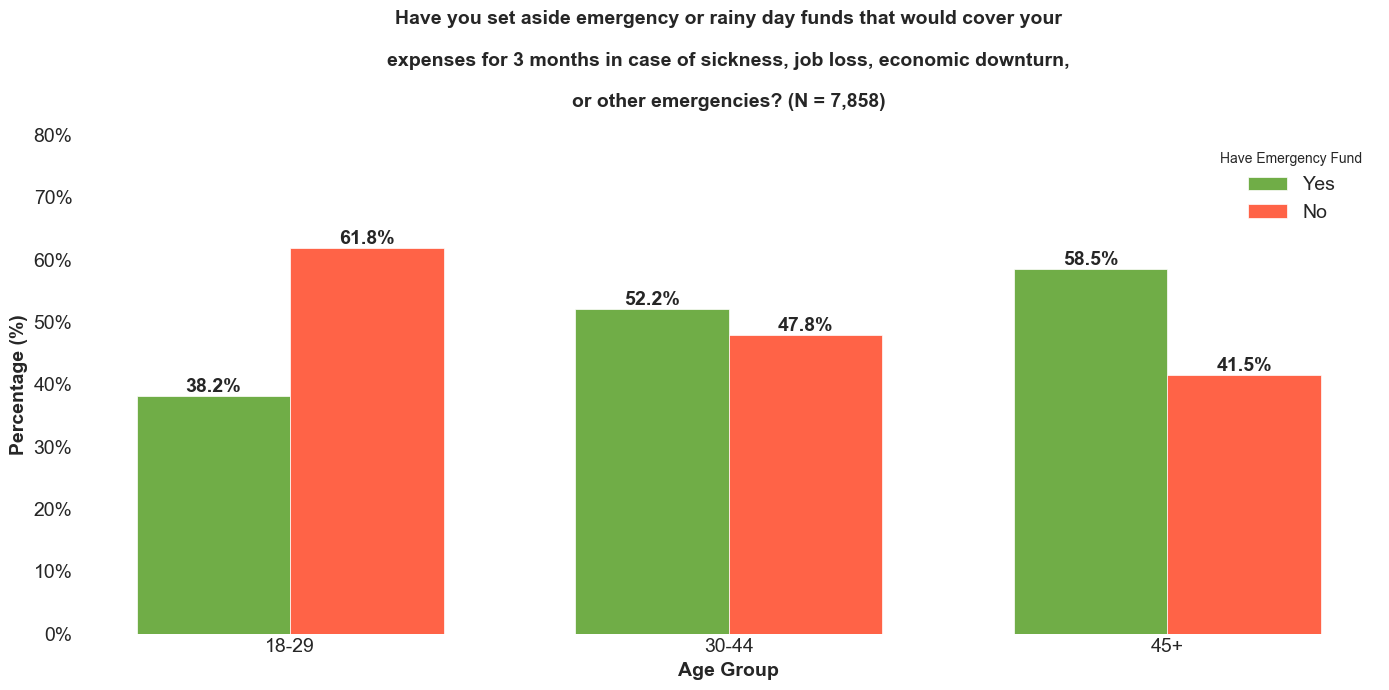


Emergency/Rainy Day Funds by Age:
EF1           Yes    No
age_3groups            
18-29       38.20 61.80
30-44       52.20 47.80
45+         58.50 41.50

Total respondents included: 7,858


In [73]:
# Chart 2: Emergency Savings Fund (EF1) by Age

# Filter data
df_chart2 = df[df['age_3groups'].isin(age_groups) & df['EF1'].notna()].copy()

# Create crosstab with percentages
ef1_by_age = pd.crosstab(df_chart2['age_3groups'], df_chart2['EF1'], normalize='index') * 100

# Define the order of EF1 categories
ef1_order = ['Yes', 'No']

# Filter to only include categories that exist in the data
ef1_order = [cat for cat in ef1_order if cat in ef1_by_age.columns]
ef1_by_age = ef1_by_age[ef1_order]

# Reindex to ensure age groups are in order
ef1_by_age = ef1_by_age.reindex(age_groups)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups))
width = 0.35

# Define colors
colors = ['#70AD47', '#FF6347']  # Green for "Yes", Red-orange for "No"

# Create bars for each EF1 category
bars = []
for i, category in enumerate(ef1_order):
    offset = (i - len(ef1_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, ef1_by_age[category], width, 
                 label=category, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=14, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title(f'Have you set aside emergency or rainy day funds that would cover your\n\nexpenses for 3 months in case of sickness, job loss, economic downturn,\n\nor other emergencies? (N = {len(df_chart2):,})',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=14, title='Have Emergency Fund')

# Remove gridlines and spines
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

ax.set_ylim(0, 80)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nEmergency/Rainy Day Funds by Age:")
print("="*60)
print(ef1_by_age.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart2):,}")

---
## Chart 3: Healthcare Cost Barriers by Age

**Variables:** E1 series - Healthcare services foregone due to cost
- E1_a: Skipped prescription drugs
- E1_b: Skipped doctor visit
- E1_c: Skipped mental health care
- E1_d: Skipped dental care
- E1_e: Skipped follow-up care

**Insight:** Healthcare access is a basic human need. If people can't afford healthcare, technology's promises of abundance ring hollow. Showing the 3 most frequent barriers by age group.

Top 3 most frequent healthcare cost barriers (average across all ages):
Dental care          21.14
Doctor visit         18.98
Mental health care   12.56
dtype: float64

Selected variables for chart: ['Dental care', 'Doctor visit', 'Mental health care']


/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_8713/3966660611.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_age = df_chart3[df_chart3[var].notna()].groupby('age_3groups').apply(
/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_8713/3966660611.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_age = df_chart3[df_chart3[var].notna()].groupby('age_3groups').apply(
/var/folde

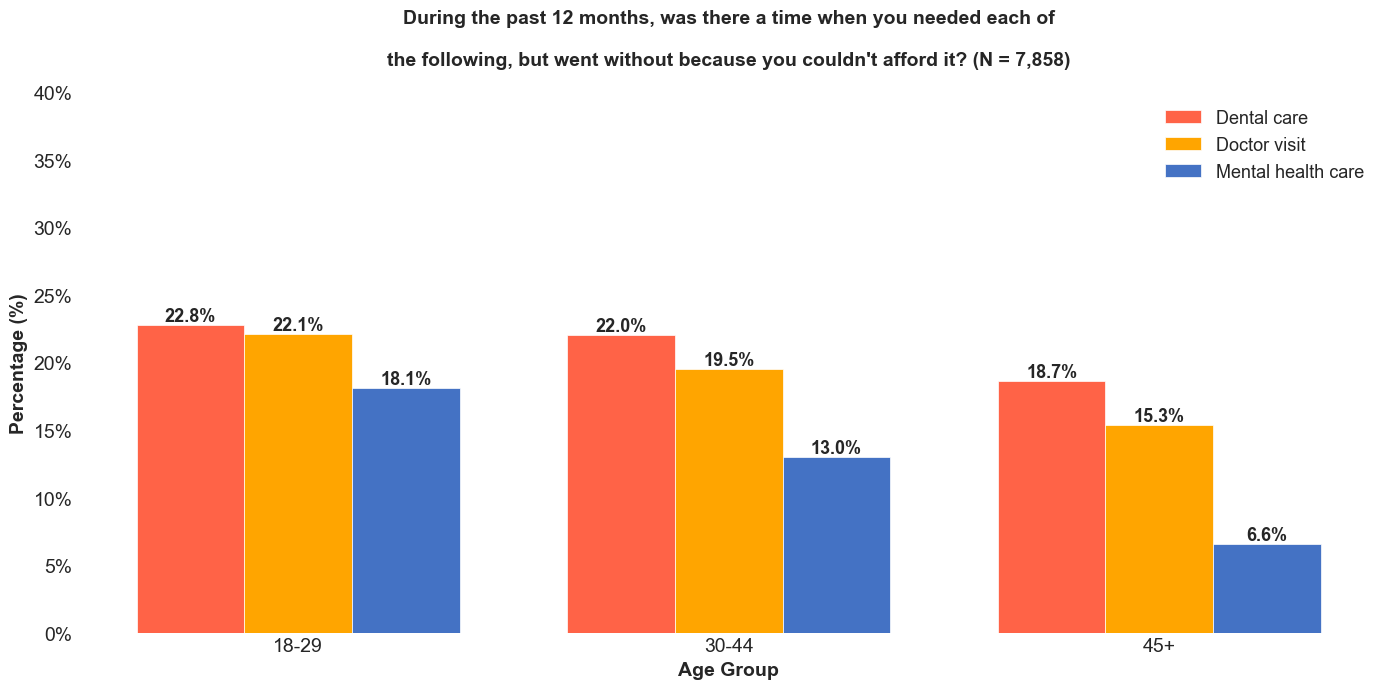


Healthcare Cost Barriers by Age (Top 3):
             Dental care  Doctor visit  Mental health care
age_3groups                                               
18-29              22.80         22.10               18.10
30-44              22.00         19.50               13.00
45+                18.70         15.30                6.60

Total respondents with at least one response: 7,858


In [74]:
# Chart 3: Healthcare Cost Barriers (E1 series) by Age - Top 3 Variables

# Define the E1 variables
e1_vars = {
    'E1_a': 'Prescription drugs',
    'E1_b': 'Doctor visit',
    'E1_c': 'Mental health care',
    'E1_d': 'Dental care',
    'E1_e': 'Follow-up care'
}

# Filter data for age groups
df_chart3 = df[df['age_3groups'].isin(age_groups)].copy()

# Calculate percentages for each healthcare barrier by age group
e1_by_age = pd.DataFrame()

for var, label in e1_vars.items():
    if var in df_chart3.columns:
        pct_by_age = df_chart3[df_chart3[var].notna()].groupby('age_3groups').apply(
            lambda x: (x[var] == 'Yes').sum() / len(x) * 100
        )
        e1_by_age[label] = pct_by_age

# Reindex to ensure age groups are in order
e1_by_age = e1_by_age.reindex(age_groups)

# Calculate average across all age groups for each variable to find top 3
avg_by_var = e1_by_age.mean(axis=0).sort_values(ascending=False)
top_3_vars = avg_by_var.head(3).index.tolist()

# Filter to top 3 variables
e1_by_age_top3 = e1_by_age[top_3_vars]

print("Top 3 most frequent healthcare cost barriers (average across all ages):")
print(avg_by_var.head(3))
print("\nSelected variables for chart:", top_3_vars)

# Calculate sample size: respondents who answered at least one of the top 3 E1 variables
# Map back from labels to variable names
label_to_var = {v: k for k, v in e1_vars.items()}
top_3_var_names = [label_to_var[label] for label in top_3_vars]

# Count respondents with at least one non-null response to the top 3 variables
df_chart3_filtered = df_chart3[df_chart3['age_3groups'].isin(age_groups)].copy()
df_chart3_filtered['has_e1_response'] = df_chart3_filtered[top_3_var_names].notna().any(axis=1)
sample_size = df_chart3_filtered['has_e1_response'].sum()

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups))
width = 0.25

# Define colors
colors = ['#FF6347', '#FFA500', '#4472C4']  # Red-orange, Orange, Blue

# Create bars for each healthcare barrier category
bars = []
for i, healthcare in enumerate(top_3_vars):
    offset = (i - len(top_3_vars)/2 + 0.5) * width
    bar = ax.bar(x + offset, e1_by_age_top3[healthcare], width, 
                 label=healthcare, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=13, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title(f'During the past 12 months, was there a time when you needed each of\n\nthe following, but went without because you couldn\'t afford it? (N = {sample_size:,})',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=13)

# Remove gridlines and spines
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

ax.set_ylim(0, 40)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nHealthcare Cost Barriers by Age (Top 3):")
print("="*60)
print(e1_by_age_top3.round(1).to_string())
print(f"\nTotal respondents with at least one response: {sample_size:,}")

---
## Chart 4: Income Variability by Age

**Variable:** I9 - Month-to-month income stability

**Insight:** Income stability is foundational. Volatility prevents people from planning for the future and forces short-term survival mode.

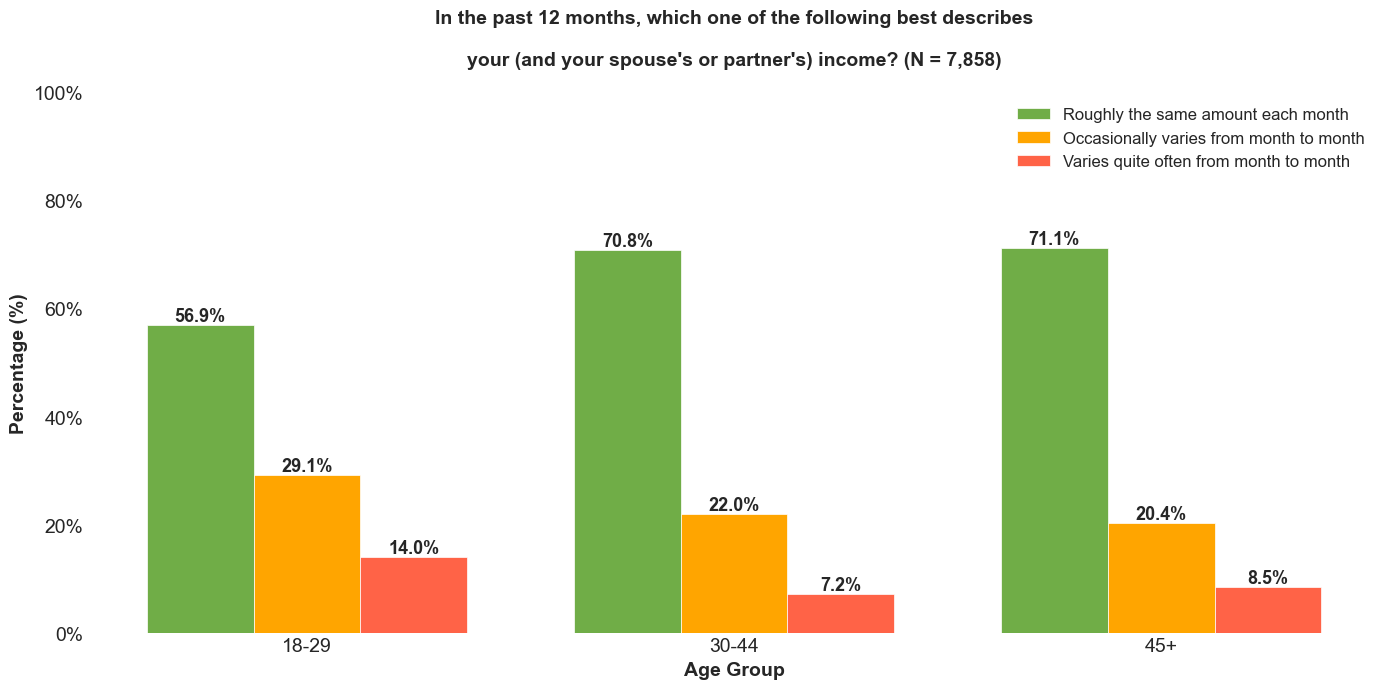


Income Variability by Age:
I9           Roughly the same amount each month  Occasionally varies from month to month  Varies quite often from month to month
age_3groups                                                                                                                     
18-29                                     56.90                                    29.10                                   14.00
30-44                                     70.80                                    22.00                                    7.20
45+                                       71.10                                    20.40                                    8.50

Total respondents included: 7,858


In [75]:
# Chart 4: Income Variability (I9) by Age

# Filter data
df_chart4 = df[df['age_3groups'].isin(age_groups) & df['I9'].notna()].copy()

# Create crosstab with percentages
i9_by_age = pd.crosstab(df_chart4['age_3groups'], df_chart4['I9'], normalize='index') * 100

# Define the order of I9 categories (from most stable to least stable)
i9_order = ['Roughly the same amount each month', 'Occasionally varies from month to month', 'Varies quite often from month to month']

# Filter to only include categories that exist in the data
i9_order = [cat for cat in i9_order if cat in i9_by_age.columns]
i9_by_age = i9_by_age[i9_order]

# Reindex to ensure age groups are in order
i9_by_age = i9_by_age.reindex(age_groups)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups))
width = 0.25

# Define colors (green for stable, red-orange for unstable)
colors = ['#70AD47', '#FFA500', '#FF6347']  # Green, Orange, Red-orange

# Create bars for each I9 category
bars = []
for i, category in enumerate(i9_order):
    offset = (i - len(i9_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, i9_by_age[category], width, 
                 label=category, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=13, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title(f'In the past 12 months, which one of the following best describes\n\nyour (and your spouse\'s or partner\'s) income? (N = {len(df_chart4):,})',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=12, bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nIncome Variability by Age:")
print("="*60)
print(i9_by_age.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart4):,}")

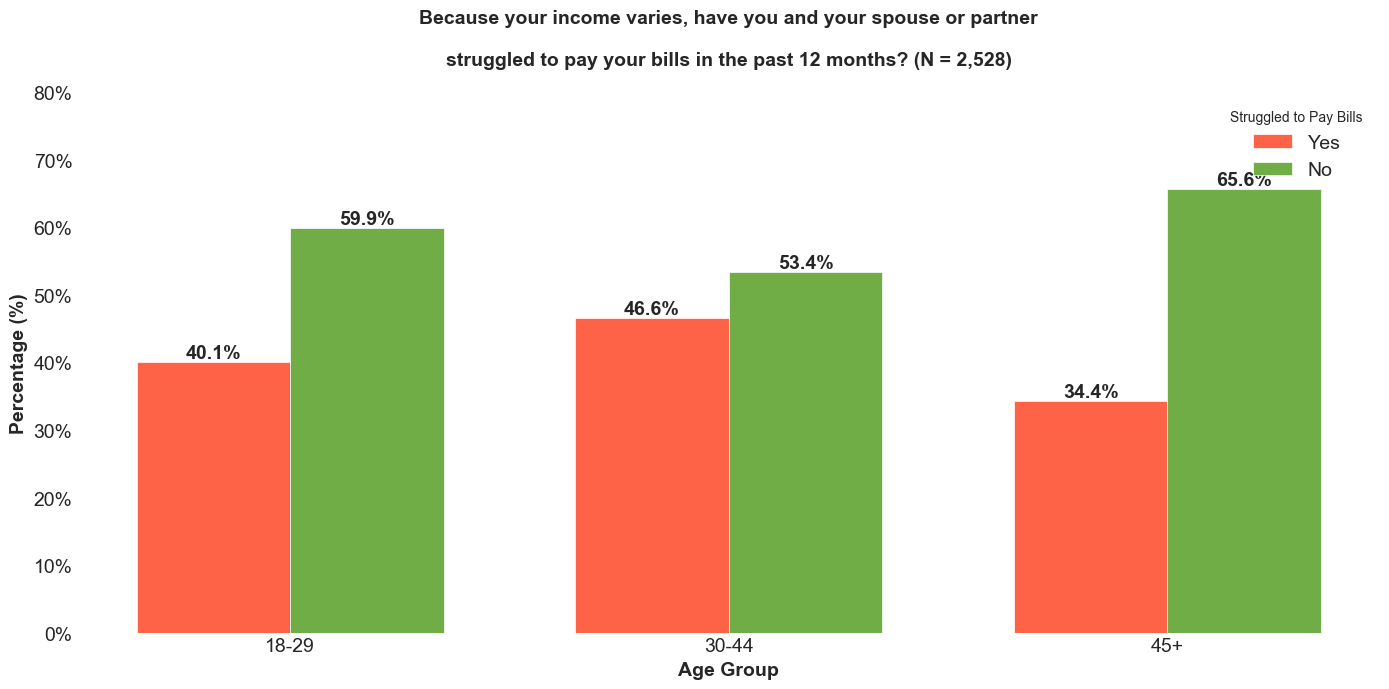


Struggled to Pay Bills Due to Income Variability by Age:
I12           Yes    No
age_3groups            
18-29       40.10 59.90
30-44       46.60 53.40
45+         34.40 65.60

Total respondents included: 2,528


In [76]:
# Chart 4b: Struggled to Pay Bills Due to Income Variability (I12) by Age

# Filter data for those with variable income who answered I12
df_chart4b = df[df['age_3groups'].isin(age_groups) & df['I12'].notna()].copy()

# Create crosstab with percentages
i12_by_age = pd.crosstab(df_chart4b['age_3groups'], df_chart4b['I12'], normalize='index') * 100

# Define the order of I12 categories
i12_order = ['Yes', 'No']

# Filter to only include categories that exist in the data
i12_order = [cat for cat in i12_order if cat in i12_by_age.columns]
i12_by_age = i12_by_age[i12_order]

# Reindex to ensure age groups are in order
i12_by_age = i12_by_age.reindex(age_groups)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups))
width = 0.35

# Define colors
colors = ['#FF6347', '#70AD47']  # Red-orange for "Yes", Green for "No"

# Create bars for each I12 category
bars = []
for i, category in enumerate(i12_order):
    offset = (i - len(i12_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, i12_by_age[category], width, 
                 label=category, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=14, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title(f'Because your income varies, have you and your spouse or partner\n\nstruggled to pay your bills in the past 12 months? (N = {len(df_chart4b):,})',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=14, title='Struggled to Pay Bills')

# Remove gridlines and spines
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

ax.set_ylim(0, 80)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nStruggled to Pay Bills Due to Income Variability by Age:")
print("="*60)
print(i12_by_age.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart4b):,}")

# Chart 5: Actions Taken Due to Price Increases (INF3 series) by Age

# Define the INF3 variables to include
inf3_vars = {
    'INF3_a': 'Used savings',
    'INF3_b': 'Borrowed money/used credit',
    'INF3_c': 'Reduced spending on essentials',
    'INF3_e': 'Worked more/additional job'
}

# Filter data for age groups
df_chart5 = df[df['age_3groups'].isin(age_groups)].copy()

# Calculate percentages for each action by age group
inf3_by_age = pd.DataFrame()

for var, label in inf3_vars.items():
    if var in df_chart5.columns:
        pct_by_age = df_chart5[df_chart5[var].notna()].groupby('age_3groups').apply(
            lambda x: (x[var] == 'Yes').sum() / len(x) * 100
        )
        inf3_by_age[label] = pct_by_age

# Reindex to ensure age groups are in order
inf3_by_age = inf3_by_age.reindex(age_groups)

# Calculate sample size: respondents who answered at least one of the INF3 variables
inf3_var_names = list(inf3_vars.keys())
df_chart5_filtered = df_chart5[df_chart5['age_3groups'].isin(age_groups)].copy()
df_chart5_filtered['has_inf3_response'] = df_chart5_filtered[inf3_var_names].notna().any(axis=1)
sample_size = df_chart5_filtered['has_inf3_response'].sum()

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups))
width = 0.2

# Define colors
colors = ['#4472C4', '#FF6347', '#FFA500', '#70AD47']  # Blue, Red-orange, Orange, Green

# Create bars for each action category
bars = []
action_labels = list(inf3_vars.values())

for i, action in enumerate(action_labels):
    if action in inf3_by_age.columns:
        offset = (i - len(action_labels)/2 + 0.5) * width
        bar = ax.bar(x + offset, inf3_by_age[action], width, 
                     label=action, color=colors[i], edgecolor='white', linewidth=0.5)
        bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title(f'Did you take any of the following actions because of increases\n\nin prices over the past 12 months? (N = {sample_size:,})',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=12, bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

ax.set_ylim(0, 90)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nActions Taken Due to Price Increases by Age:")
print("="*60)
print(inf3_by_age.round(1).to_string())
print(f"\nTotal respondents with at least one response: {sample_size:,}")

---
## Chart 5: Actions Taken Due to Price Increases by Age

**Variables:** INF3 series - Responses to inflation

**Insight:** Shows how economic stress forces people into short-term survival mode - depleting savings, borrowing, cutting back, working more.

/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_8713/3012261228.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_age = df_chart5[df_chart5[var].notna()].groupby('age_3groups').apply(
/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_8713/3012261228.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_age = df_chart5[df_chart5[var].notna()].groupby('age_3groups').apply(
/var/folde

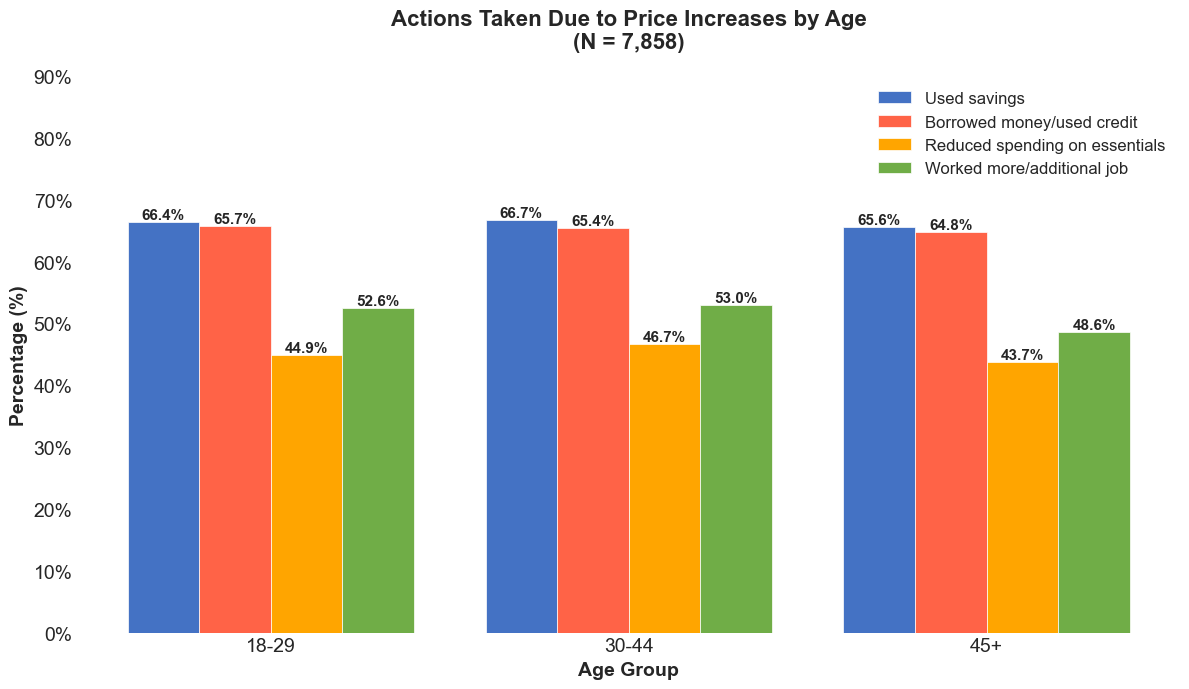


Actions Taken Due to Price Increases by Age:
             Used savings  Borrowed money/used credit  Reduced spending on essentials  Worked more/additional job
age_3groups                                                                                                      
18-29               66.40                       65.70                           44.90                       52.60
30-44               66.70                       65.40                           46.70                       53.00
45+                 65.60                       64.80                           43.70                       48.60

Total respondents with at least one response: 7,858


In [77]:
# Chart 5: Actions Taken Due to Price Increases (INF3 series) by Age

# Define the INF3 variables to include
inf3_vars = {
    'INF3_a': 'Used savings',
    'INF3_b': 'Borrowed money/used credit',
    'INF3_c': 'Reduced spending on essentials',
    'INF3_e': 'Worked more/additional job'
}

# Filter data for age groups
df_chart5 = df[df['age_3groups'].isin(age_groups)].copy()

# Calculate percentages for each action by age group
inf3_by_age = pd.DataFrame()

for var, label in inf3_vars.items():
    if var in df_chart5.columns:
        pct_by_age = df_chart5[df_chart5[var].notna()].groupby('age_3groups').apply(
            lambda x: (x[var] == 'Yes').sum() / len(x) * 100
        )
        inf3_by_age[label] = pct_by_age

# Reindex to ensure age groups are in order
inf3_by_age = inf3_by_age.reindex(age_groups)

# Calculate sample size: respondents who answered at least one of the INF3 variables
inf3_var_names = list(inf3_vars.keys())
df_chart5_filtered = df_chart5[df_chart5['age_3groups'].isin(age_groups)].copy()
df_chart5_filtered['has_inf3_response'] = df_chart5_filtered[inf3_var_names].notna().any(axis=1)
sample_size = df_chart5_filtered['has_inf3_response'].sum()

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups))
width = 0.2

# Define colors
colors = ['#4472C4', '#FF6347', '#FFA500', '#70AD47']  # Blue, Red-orange, Orange, Green

# Create bars for each action category
bars = []
action_labels = list(inf3_vars.values())

for i, action in enumerate(action_labels):
    if action in inf3_by_age.columns:
        offset = (i - len(action_labels)/2 + 0.5) * width
        bar = ax.bar(x + offset, inf3_by_age[action], width, 
                     label=action, color=colors[i], edgecolor='white', linewidth=0.5)
        bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title(f'Actions Taken Due to Price Increases by Age\n(N = {sample_size:,})', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=12, bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

ax.set_ylim(0, 90)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nActions Taken Due to Price Increases by Age:")
print("="*60)
print(inf3_by_age.round(1).to_string())
print(f"\nTotal respondents with at least one response: {sample_size:,}")

---
## Chart 6: Financial Concerns by Age

**Variables:** X12 series - Major financial concerns
- X12_c: Housing costs or availability
- X12_e: Making ends meet
- X12_f: Medical debt or affording medical care

**Insight:** Shows people's self-identified pain points. These are the issues keeping people up at night.

/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_8713/639357662.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_age = df_chart6[df_chart6[var].notna()].groupby('age_3groups').apply(
/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_8713/639357662.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_age = df_chart6[df_chart6[var].notna()].groupby('age_3groups').apply(
/var/folders

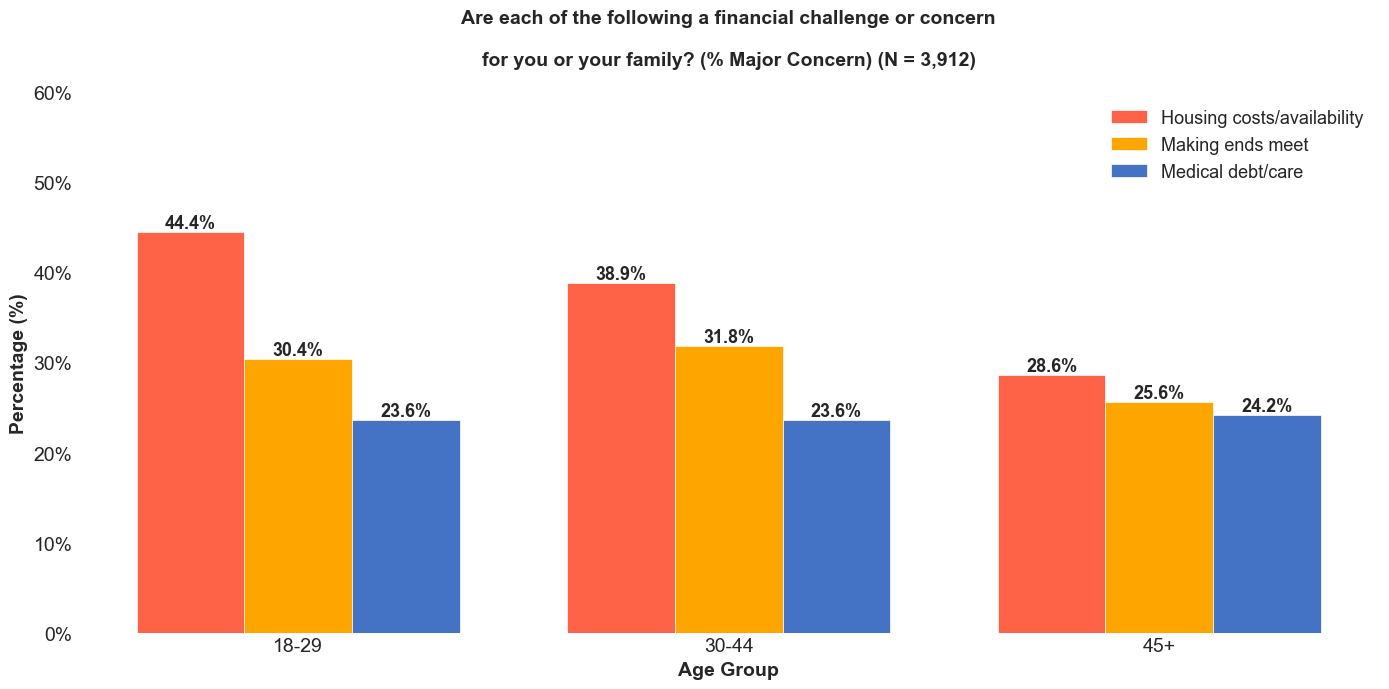


Major Financial Concerns by Age:
             Housing costs/availability  Making ends meet  Medical debt/care
age_3groups                                                                 
18-29                             44.40             30.40              23.60
30-44                             38.90             31.80              23.60
45+                               28.60             25.60              24.20

Total respondents with at least one response: 3,912


In [78]:
# Chart 6: Financial Concerns (X12 series) by Age

# Define the X12 variables for major concerns
x12_vars = {
    'X12_c': 'Housing costs/availability',
    'X12_e': 'Making ends meet',
    'X12_f': 'Medical debt/care'
}

# Filter data for age groups
df_chart6 = df[df['age_3groups'].isin(age_groups)].copy()

# Calculate percentages for "Major concern" by age group
x12_by_age = pd.DataFrame()

for var, label in x12_vars.items():
    if var in df_chart6.columns:
        pct_by_age = df_chart6[df_chart6[var].notna()].groupby('age_3groups').apply(
            lambda x: (x[var] == 'Major concern').sum() / len(x) * 100
        )
        x12_by_age[label] = pct_by_age

# Reindex to ensure age groups are in order
x12_by_age = x12_by_age.reindex(age_groups)

# Calculate sample size
x12_var_names = list(x12_vars.keys())
df_chart6_filtered = df_chart6[df_chart6['age_3groups'].isin(age_groups)].copy()
df_chart6_filtered['has_x12_response'] = df_chart6_filtered[x12_var_names].notna().any(axis=1)
sample_size = df_chart6_filtered['has_x12_response'].sum()

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups))
width = 0.25

# Define colors
colors = ['#FF6347', '#FFA500', '#4472C4']  # Red-orange, Orange, Blue

# Create bars for each concern category
bars = []
concern_labels = list(x12_vars.values())

for i, concern in enumerate(concern_labels):
    if concern in x12_by_age.columns:
        offset = (i - len(concern_labels)/2 + 0.5) * width
        bar = ax.bar(x + offset, x12_by_age[concern], width, 
                     label=concern, color=colors[i], edgecolor='white', linewidth=0.5)
        bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=13, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title(f'Are each of the following a financial challenge or concern\n\nfor you or your family? (% Major Concern) (N = {sample_size:,})',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=13)

# Remove gridlines and spines
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

ax.set_ylim(0, 60)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nMajor Financial Concerns by Age:")
print("="*60)
print(x12_by_age.round(1).to_string())
print(f"\nTotal respondents with at least one response: {sample_size:,}")

/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_8713/400979217.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_age = df_chart7[df_chart7[var].notna()].groupby('age_3groups').apply(
/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_8713/400979217.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_age = df_chart7[df_chart7[var].notna()].groupby('age_3groups').apply(
/var/folders

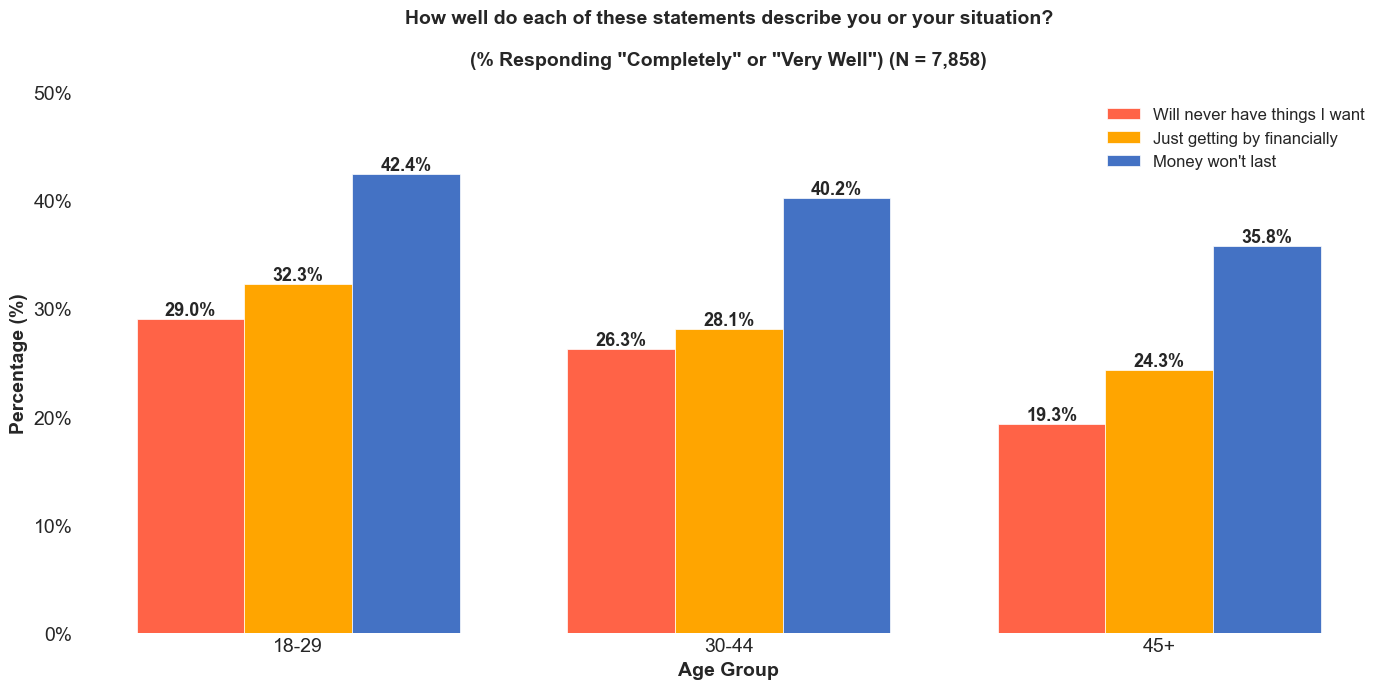


Financial Outlook by Age (Completely/Very Well):
             Will never have things I want  Just getting by financially  Money won't last
age_3groups                                                                              
18-29                                29.00                        32.30             42.40
30-44                                26.30                        28.10             40.20
45+                                  19.30                        24.30             35.80

Total respondents with at least one response: 7,858


In [79]:
# Chart 7: Financial Outlook (B0 series) by Age

# Define the B0 variables
b0_vars = {
    'B0_a': 'Will never have things I want',
    'B0_b': 'Just getting by financially',
    'B0_c': 'Money won\'t last'
}

# Filter data for age groups
df_chart7 = df[df['age_3groups'].isin(age_groups)].copy()

# Calculate percentages for "Completely" or "Very well" responses by age group
b0_by_age = pd.DataFrame()

for var, label in b0_vars.items():
    if var in df_chart7.columns:
        pct_by_age = df_chart7[df_chart7[var].notna()].groupby('age_3groups').apply(
            lambda x: (x[var].isin(['Completely', 'Very well'])).sum() / len(x) * 100
        )
        b0_by_age[label] = pct_by_age

# Reindex to ensure age groups are in order
b0_by_age = b0_by_age.reindex(age_groups)

# Calculate sample size
b0_var_names = list(b0_vars.keys())
df_chart7_filtered = df_chart7[df_chart7['age_3groups'].isin(age_groups)].copy()
df_chart7_filtered['has_b0_response'] = df_chart7_filtered[b0_var_names].notna().any(axis=1)
sample_size = df_chart7_filtered['has_b0_response'].sum()

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups))
width = 0.25

# Define colors
colors = ['#FF6347', '#FFA500', '#4472C4']  # Red-orange, Orange, Blue

# Create bars for each B0 statement
bars = []
b0_labels = list(b0_vars.values())

for i, statement in enumerate(b0_labels):
    if statement in b0_by_age.columns:
        offset = (i - len(b0_labels)/2 + 0.5) * width
        bar = ax.bar(x + offset, b0_by_age[statement], width, 
                     label=statement, color=colors[i], edgecolor='white', linewidth=0.5)
        bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=13, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title(f'How well do each of these statements describe you or your situation?\n\n(% Responding "Completely" or "Very Well") (N = {sample_size:,})',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=12, bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

ax.set_ylim(0, 50)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nFinancial Outlook by Age (Completely/Very Well):")
print("="*60)
print(b0_by_age.round(1).to_string())
print(f"\nTotal respondents with at least one response: {sample_size:,}")

/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_8713/593424575.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_age = df_chart8[df_chart8['B1_a'].notna()].groupby('age_3groups').apply(
/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_8713/593424575.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_age = df_chart8[df_chart8['B1_b'].notna()].groupby('age_3groups').apply(


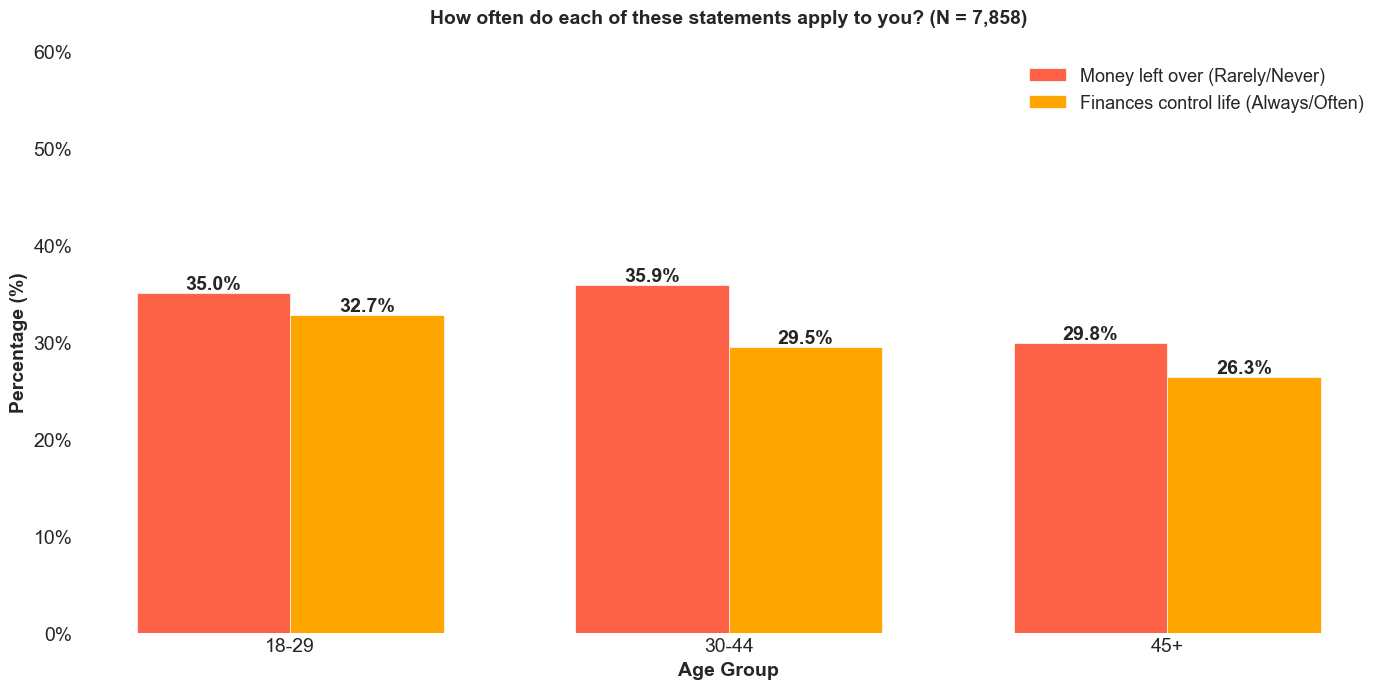


Financial Frequency Indicators by Age:
             Money left over (Rarely/Never)  Finances control life (Always/Often)
age_3groups                                                                      
18-29                                 35.00                                 32.70
30-44                                 35.90                                 29.50
45+                                   29.80                                 26.30

Total respondents with at least one response: 7,858


In [80]:
# Chart 8: Financial Frequency Indicators (B1 series) by Age

# Define the B1 variables
b1_vars = {
    'B1_a': 'Money left over (Rarely/Never)',
    'B1_b': 'Finances control life (Always/Often)'
}

# Filter data for age groups
df_chart8 = df[df['age_3groups'].isin(age_groups)].copy()

# Calculate percentages by age group
b1_by_age = pd.DataFrame()

# For B1_a, calculate % who say "Rarely" or "Never" (negative indicator)
if 'B1_a' in df_chart8.columns:
    pct_by_age = df_chart8[df_chart8['B1_a'].notna()].groupby('age_3groups').apply(
        lambda x: (x['B1_a'].isin(['Rarely', 'Never'])).sum() / len(x) * 100
    )
    b1_by_age[b1_vars['B1_a']] = pct_by_age

# For B1_b, calculate % who say "Always" or "Often" (negative indicator)
if 'B1_b' in df_chart8.columns:
    pct_by_age = df_chart8[df_chart8['B1_b'].notna()].groupby('age_3groups').apply(
        lambda x: (x['B1_b'].isin(['Always', 'Often'])).sum() / len(x) * 100
    )
    b1_by_age[b1_vars['B1_b']] = pct_by_age

# Reindex to ensure age groups are in order
b1_by_age = b1_by_age.reindex(age_groups)

# Calculate sample size
b1_var_names = ['B1_a', 'B1_b']
df_chart8_filtered = df_chart8[df_chart8['age_3groups'].isin(age_groups)].copy()
df_chart8_filtered['has_b1_response'] = df_chart8_filtered[b1_var_names].notna().any(axis=1)
sample_size = df_chart8_filtered['has_b1_response'].sum()

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups))
width = 0.35

# Define colors
colors = ['#FF6347', '#FFA500']  # Red-orange, Orange

# Create bars for each B1 indicator
bars = []
b1_labels = list(b1_vars.values())

for i, indicator in enumerate(b1_labels):
    if indicator in b1_by_age.columns:
        offset = (i - len(b1_labels)/2 + 0.5) * width
        bar = ax.bar(x + offset, b1_by_age[indicator], width, 
                     label=indicator, color=colors[i], edgecolor='white', linewidth=0.5)
        bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=14, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title(f'How often do each of these statements apply to you? (N = {sample_size:,})', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=13)

# Remove gridlines and spines
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

ax.set_ylim(0, 60)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nFinancial Frequency Indicators by Age:")
print("="*60)
print(b1_by_age.round(1).to_string())
print(f"\nTotal respondents with at least one response: {sample_size:,}")

/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_8713/3556944778.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_age = df_chart9[df_chart9[var].notna()].groupby('age_3groups').apply(
/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_8713/3556944778.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_age = df_chart9[df_chart9[var].notna()].groupby('age_3groups').apply(


Top 3 most frequent retirement account actions (average across all ages):
Reduced contributions      8.11
Borrowed from retirement   5.00
Cashed out retirement      4.38
dtype: float64

Selected variables for chart: ['Reduced contributions', 'Borrowed from retirement', 'Cashed out retirement']


/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_8713/3556944778.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_age = df_chart9[df_chart9[var].notna()].groupby('age_3groups').apply(


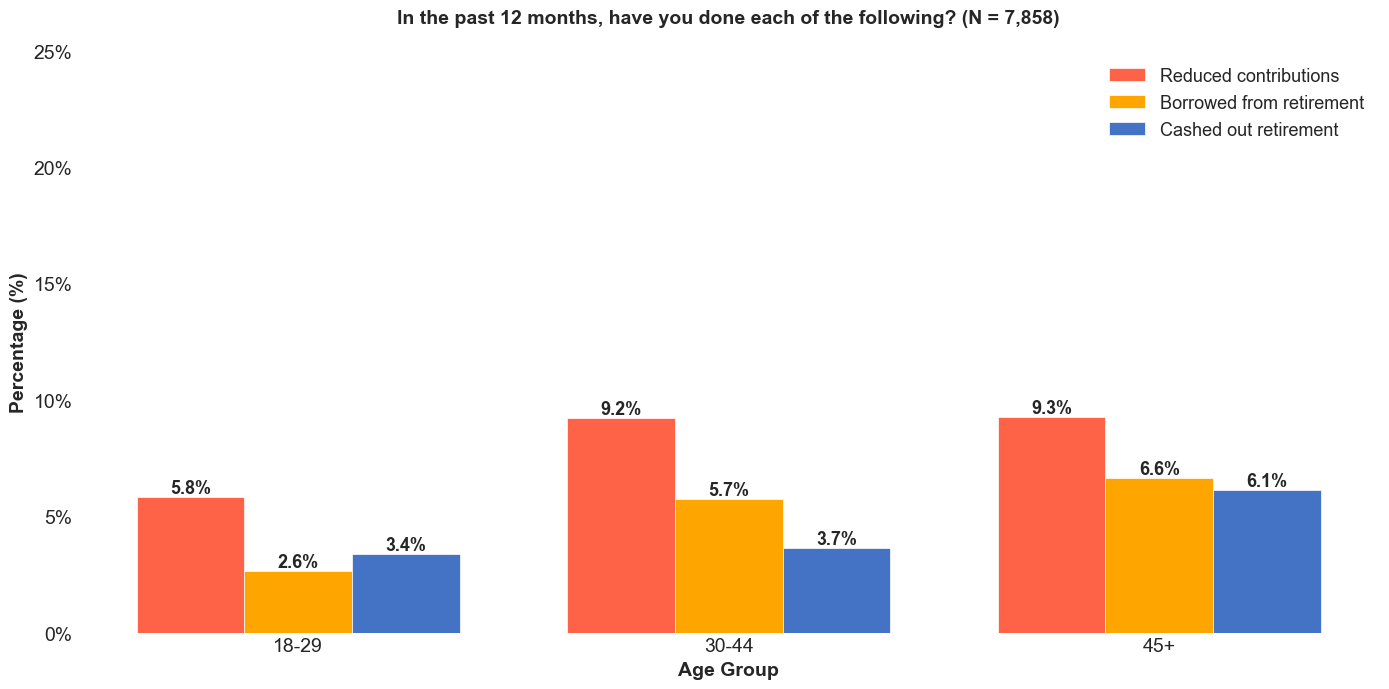


Retirement Account Stress Actions by Age (Top 3):
             Reduced contributions  Borrowed from retirement  Cashed out retirement
age_3groups                                                                        
18-29                         5.80                      2.60                   3.40
30-44                         9.20                      5.70                   3.70
45+                           9.30                      6.60                   6.10

Total respondents with at least one response: 7,858


In [81]:
# Chart 9: Retirement Account Stress (K5A series) by Age - Top 3

# Define the K5A variables
k5a_vars = {
    'K5A_a': 'Borrowed from retirement',
    'K5A_b': 'Cashed out retirement',
    'K5A_c': 'Reduced contributions'
}

# Filter data for age groups
df_chart9 = df[df['age_3groups'].isin(age_groups)].copy()

# Calculate percentages for each action by age group
k5a_by_age = pd.DataFrame()

for var, label in k5a_vars.items():
    if var in df_chart9.columns:
        pct_by_age = df_chart9[df_chart9[var].notna()].groupby('age_3groups').apply(
            lambda x: (x[var] == 'Yes').sum() / len(x) * 100
        )
        k5a_by_age[label] = pct_by_age

# Reindex to ensure age groups are in order
k5a_by_age = k5a_by_age.reindex(age_groups)

# Calculate average across all age groups for each variable to find top 3
avg_by_var = k5a_by_age.mean(axis=0).sort_values(ascending=False)
top_3_vars = avg_by_var.head(3).index.tolist()

# Filter to top 3 variables
k5a_by_age_top3 = k5a_by_age[top_3_vars]

print("Top 3 most frequent retirement account actions (average across all ages):")
print(avg_by_var.head(3))
print("\nSelected variables for chart:", top_3_vars)

# Calculate sample size
k5a_var_names = list(k5a_vars.keys())
df_chart9_filtered = df_chart9[df_chart9['age_3groups'].isin(age_groups)].copy()
df_chart9_filtered['has_k5a_response'] = df_chart9_filtered[k5a_var_names].notna().any(axis=1)
sample_size = df_chart9_filtered['has_k5a_response'].sum()

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups))
width = 0.25

# Define colors
colors = ['#FF6347', '#FFA500', '#4472C4']  # Red-orange, Orange, Blue

# Create bars for each retirement action
bars = []
for i, action in enumerate(top_3_vars):
    offset = (i - len(top_3_vars)/2 + 0.5) * width
    bar = ax.bar(x + offset, k5a_by_age_top3[action], width, 
                 label=action, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=13, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title(f'In the past 12 months, have you done each of the following? (N = {sample_size:,})',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=13)

# Remove gridlines and spines
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

ax.set_ylim(0, 25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nRetirement Account Stress Actions by Age (Top 3):")
print("="*60)
print(k5a_by_age_top3.round(1).to_string())
print(f"\nTotal respondents with at least one response: {sample_size:,}")

---
## Chart 9: Retirement Account Stress by Age

**Variables:** K5A series - Actions taken with retirement accounts in past 12 months
- K5A_a: Borrowed money from retirement accounts
- K5A_b: Cashed out (permanently withdrawn) from retirement account
- K5A_c: Reduced regular contributions to retirement accounts

**Insight:** Shows people cannibalizing their future to survive the present. Top 3 most frequent actions shown.

---
## Chart 8: Financial Frequency Indicators by Age

**Variables:** B1 series - How often these statements apply
- B1_a: "I have money left over at the end of the month"
- B1_b: "My finances control my life"

**Insight:** Shows frequency of cash flow problems and financial stress.

---
## Chart 7: Financial Outlook by Age

**Variables:** B0 series - How well these statements describe you
- B0_a: "Because of my money situation, I will never have the things I want in life"
- B0_b: "I am just getting by financially"
- B0_c: "I am concerned that the money I have or will save won't last"

**Insight:** Psychological impact of financial stress. Shows despair, survival mode, and anxiety about the future.